# FigR4 reach weight dists: GD vs EG (0 and 500 irrel)

This notebook compares final recurrent weights to a log normal distribution for the GD and EG conditions.
It generates histograms with Gaussian overlays, plus bar charts for KS statistics and p-values.


In [30]:
from pathlib import Path
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
from scipy import stats

import sys
sys.path.append('../../')
sys.path.append('../')

from src import analysis_utils as au

# Colors
EG_C = "#f05039"  # orangey red
GD_C = "#1f449c"  # blue

fig_path = Path("figs/generality_analysis_weights")
fig_path.mkdir(parents=True, exist_ok=True)

from src import plot_utils as pu

['/home/mila/c/cornforj/eg_rnns/eg_reach_oc/analysis/arial.ttf']
/home/mila/c/cornforj/eg_rnns/eg_reach_oc/analysis/arial.ttf
/home/mila/c/cornforj/eg_rnns/eg_reach_oc/analysis/arial.ttf


In [31]:
linclab_drive = Path("/network/projects/_groups/linclab_users/eg/")
project_folder = linclab_drive / "reach_cosdecay"
all_exps_folder = project_folder / "6k500irrel"

exp_folders = {
    "gd_500": "rnn_2500_sgd_lr0.01_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel500_updates6000",
    "gd_0": "rnn_2500_sgd_lr0.05_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel0_updates6000",
    "eg_500": "rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000",
    "eg_0": "rnn_2500_seg_lr0.75_m0.925_wd1e-06_mxn4_bs500_cosinecooldown_nirrel0_updates6000",
}
exp_folders = {k: all_exps_folder / v for k, v in exp_folders.items()}


In [32]:
def load_results(exp_folders, verbose=False):
    results_dict = au.DotDict({})
    for exp_name, exp_folder in exp_folders.items():
        results_dict[exp_name] = au.DotDict({"exp_path": exp_folder})

    for exp_name in results_dict.keys():
        print(exp_name, end="")
        found, not_found = 0, 0
        seed_dirs = sorted(os.listdir(exp_folders[exp_name]), key=lambda x: int(x.split("_")[-1]))
        for seed_dir in seed_dirs:
            results_dict[exp_name][seed_dir] = au.DotDict({"path": results_dict[exp_name].exp_path / seed_dir})
            checkpoints = list(results_dict[exp_name][seed_dir].path.glob("*.pth"))
            if checkpoints:
                results_dict[exp_name][seed_dir]["ckpts"] = checkpoints

            try:
                results_dict[exp_name][seed_dir].results = np.load(
                    results_dict[exp_name][seed_dir].path / "results.npy", allow_pickle=True
                )[()]
                found += 1
            except Exception:
                not_found += 1

            with open(results_dict[exp_name][seed_dir].path / "config.yaml", "r") as file:
                config = au.DotDict(yaml.safe_load(file))
                results_dict[exp_name][seed_dir].cfg = au.recursive_dot_dict(config)

        if verbose:
            print(f" : loaded {found} results from {found + not_found}")
    return results_dict


def get_final_weights(exp_d):
    weight_ih_list = []
    weight_hh_list = []
    for seed_key in exp_d.keys():
        if not seed_key.startswith("seed"):
            continue
        ckpts = exp_d[seed_key]["ckpts"]
        assert str(ckpts[-1]).endswith("5999.pth")
        model_weights_pth = all_exps_folder / ckpts[-1]
        state_dict = torch.load(model_weights_pth, map_location="cpu")
        try:
            weight_hh = state_dict["policy.rnn.base_layer.weight_hh"].cpu().numpy().ravel()
            weight_ih = state_dict["policy.rnn.base_layer.weight_ih"].cpu().numpy().ravel()
        except KeyError:
            weight_hh = state_dict["policy.rnn.weight_hh"].cpu().numpy().ravel()
            weight_ih = state_dict["policy.rnn.weight_ih"].cpu().numpy().ravel()
        weight_hh_list.append(weight_hh)
        weight_ih_list.append(weight_ih)
    return weight_ih_list, weight_hh_list


In [33]:
from scipy.stats import norm

def get_norm_pdf(points, mean, std):
    return norm(loc=mean, scale=std).pdf(points)


def plot_weight_hist(
    arr,
    color,
    *,
    zero_th=None,
    log_weights=False,
    log_y_scale=False,
    stat="density",
    gaussian_approx=False,
    xlims_step=None,
    ylims_step=None,
    figsize=(1.75, 0.9),
    xlabel=r"$\log |w^{rec}|$",
):
    fig = plt.figure(figsize=figsize, dpi=300)
    ax = fig.add_subplot(111)

    arr = np.abs(arr).ravel()
    if zero_th is not None:
        arr = arr[arr > zero_th]
    if log_weights:
        arr = np.log(arr + 1e-12 * (arr == 0))

    max_weight = np.max(arr)
    bin_edges = np.linspace(min(0, np.min(arr)), max_weight, 50)

    if gaussian_approx:
        points = np.linspace(min(0, np.min(arr)), max_weight, 500)
        ax.plot(points, get_norm_pdf(points, arr.mean(), arr.std()), color=color, linestyle="--", linewidth=1)

    sns.histplot(arr, bins=bin_edges, kde=False, stat=stat, color=color, ec=None, alpha=0.6, ax=ax)

    if ylims_step is not None:
        ticks = np.arange(ylims_step[0], ylims_step[1] + ylims_step[2], ylims_step[2])
        ax.set_yticks(ticks)
        ax.set_ylim(ylims_step[0], ylims_step[1])

    if xlims_step is not None:
        ticks = np.arange(xlims_step[0], xlims_step[1] + xlims_step[2], xlims_step[2])
        ax.set_xticks(ticks)
        ax.set_xlim(xlims_step[0], xlims_step[1])

    sns.despine(offset=2, trim=True, ax=ax)
    ax.set_xlabel(xlabel)
    if log_y_scale:
        plt.yscale("log")
    #plt.show()
    return fig


In [34]:
def z_score_arr(arr, axis=0):
    mean = np.mean(arr, axis=axis)
    std = np.std(arr, axis=axis)
    return (arr - mean) / std


def zscore_and_log_list(arr_list):
    z_list = []
    for arr in arr_list:
        arr = np.abs(arr)
        arr = np.log(arr + 1e-12 * (arr == 0))
        z_list.append(z_score_arr(arr))
    return z_list


def ks_stats_from_list(arr_list):
    stats_list = []
    p_list = []
    for arr in tqdm(arr_list, desc="KS tests"):
        res = stats.kstest(arr, stats.norm.cdf)
        stats_list.append(res.statistic)
        p_list.append(res.pvalue)
    return np.array(stats_list), np.array(p_list)


In [35]:
results_dict = load_results(exp_folders, verbose=True)


gd_500 : loaded 9 results from 9
gd_0 : loaded 9 results from 9
eg_500 : loaded 9 results from 9
eg_0 : loaded 9 results from 9


## 500 irrel (GD vs EG)


/tmp/ipykernel_2767352/3878927534.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_weights_pth, map_location="cpu")


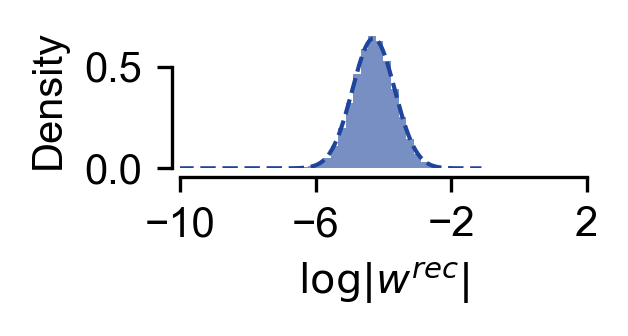

In [41]:
_, gd_weight_hh_list_500 = get_final_weights(results_dict["gd_500"])
_, eg_weight_hh_list_500 = get_final_weights(results_dict["eg_500"])

# Histograms (first seed) with Gaussian overlay
plot_weight_hist(
    gd_weight_hh_list_500[0],
    GD_C,
    log_weights=True,
    gaussian_approx=True,
    zero_th=6e-6,
    stat="density",
    xlims_step=(-10, 2, 4),
    figsize=(1.75, 0.6)
)
plt.savefig(fig_path / "Wrec_log_transform_500_gd.pdf", bbox_inches="tight", transparent=True)


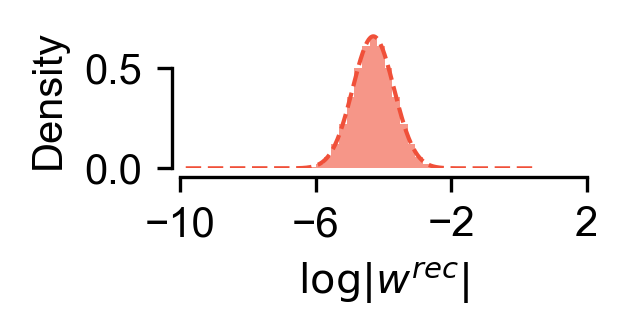

In [42]:
plot_weight_hist(
    eg_weight_hh_list_500[0],
    EG_C,
    log_weights=True,
    gaussian_approx=True,
    zero_th=6e-6,
    stat="density",
    xlims_step=(-10, 2, 4),
    figsize=(1.75, 0.6)
)

plt.savefig(fig_path / "Wrec_log_transform_500_eg.pdf", bbox_inches="tight", transparent=True)

KS tests: 100%|██████████| 9/9 [00:04<00:00,  2.08it/s]


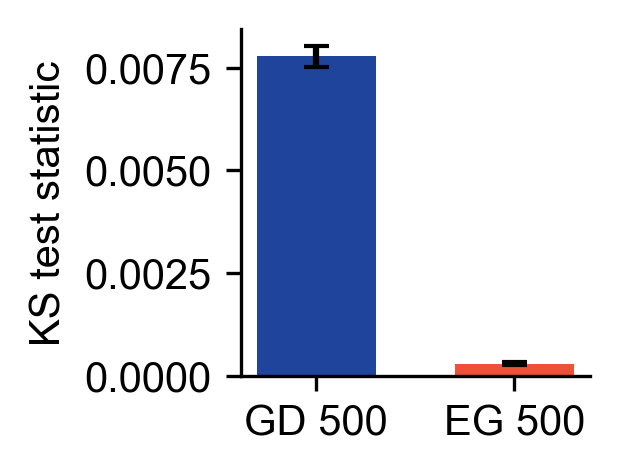

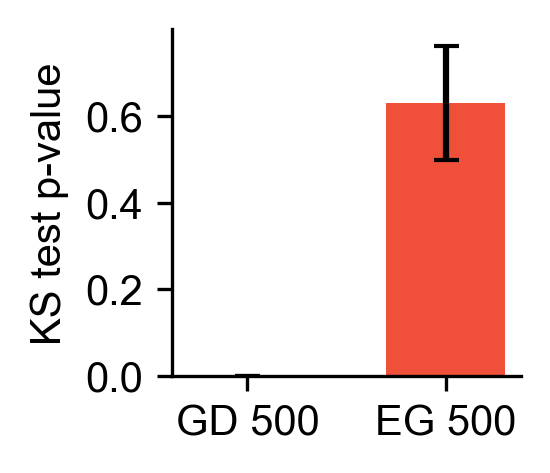

In [38]:
gd_weight_hh_list_zs_500 = zscore_and_log_list(gd_weight_hh_list_500)
eg_weight_hh_list_zs_500 = zscore_and_log_list(eg_weight_hh_list_500)

gd_stat_500, gd_p_500 = ks_stats_from_list(gd_weight_hh_list_zs_500)
eg_stat_500, eg_p_500 = ks_stats_from_list(eg_weight_hh_list_zs_500)

# KS statistic bar chart
plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.bar(["GD 500", "EG 500"], [gd_stat_500.mean(),eg_stat_500.mean()],
        yerr=[gd_stat_500.std(),eg_stat_500.std()],
        color=[GD_C, EG_C], capsize=3, width=0.6)
sns.despine()
plt.ylabel("KS test statistic")
plt.savefig(fig_path / "KS_stat_500.pdf", bbox_inches="tight", transparent=True)
plt.show()

# KS p-value bar chart
plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.bar(["GD 500", "EG 500"], [gd_p_500.mean(), eg_p_500.mean()],
        yerr=[gd_p_500.std(), eg_p_500.std()],
        color=[GD_C, EG_C], capsize=3, width=0.6)
sns.despine()
plt.ylabel("KS test p-value")
plt.savefig(fig_path / "KS_p_500.pdf", bbox_inches="tight", transparent=True)
plt.show()


## 0 irrel (GD vs EG)


/tmp/ipykernel_2767352/3878927534.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_weights_pth, map_location="cpu")


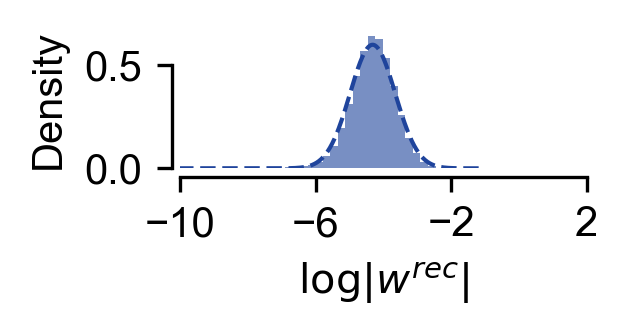

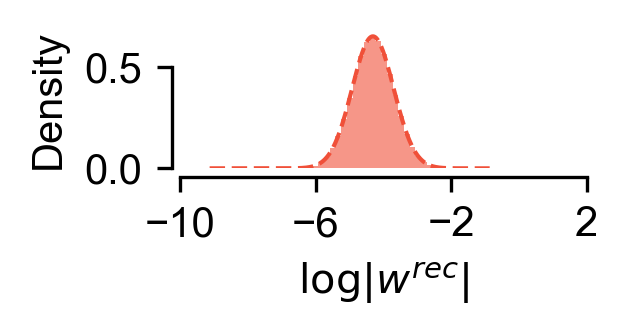

In [43]:
_, gd_weight_hh_list_0 = get_final_weights(results_dict["gd_0"])
_, eg_weight_hh_list_0 = get_final_weights(results_dict["eg_0"])

# Histograms (first seed) with Gaussian overlay
plot_weight_hist(
    gd_weight_hh_list_0[0],
    GD_C,
    log_weights=True,
    gaussian_approx=True,
    zero_th=6e-6,
    stat="density",
    xlims_step=(-10, 2, 4),
    figsize=(1.75, 0.6)
)
plt.savefig(fig_path / "Wrec_log_transform_0_gd.pdf", bbox_inches="tight", transparent=True)


plot_weight_hist(
    eg_weight_hh_list_0[0],
    EG_C,
    log_weights=True,
    gaussian_approx=True,
    zero_th=6e-6,
    stat="density",
    xlims_step=(-10, 2, 4),
    figsize=(1.75, 0.6)
);

plt.savefig(fig_path / "Wrec_log_transform_0_eg.pdf", bbox_inches="tight", transparent=True)


KS tests: 100%|██████████| 9/9 [00:04<00:00,  2.11it/s]


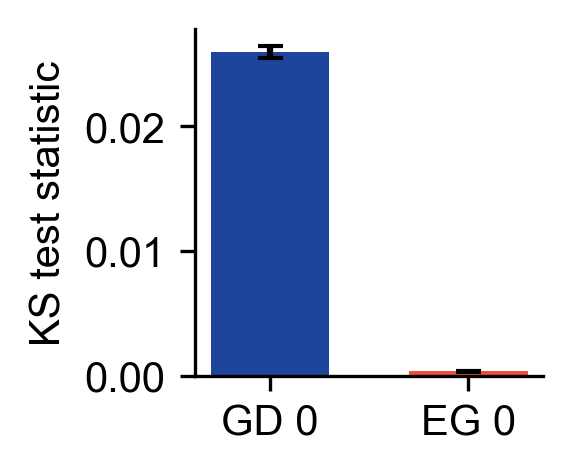

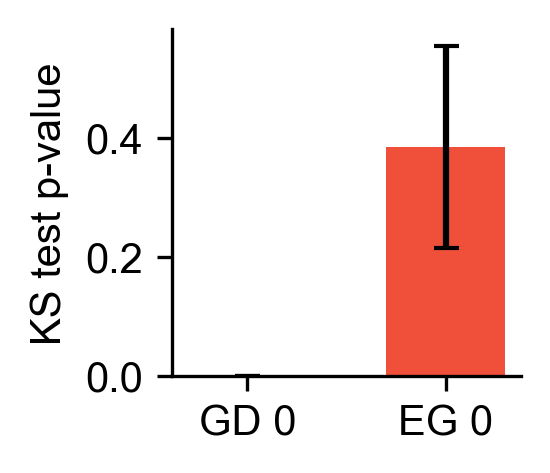

In [40]:
gd_weight_hh_list_zs_0 = zscore_and_log_list(gd_weight_hh_list_0)
eg_weight_hh_list_zs_0 = zscore_and_log_list(eg_weight_hh_list_0)

gd_stat_0, gd_p_0 = ks_stats_from_list(gd_weight_hh_list_zs_0)
eg_stat_0, eg_p_0 = ks_stats_from_list(eg_weight_hh_list_zs_0)

# KS statistic bar chart
plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.bar(["GD 0", "EG 0"], [gd_stat_0.mean(),eg_stat_0.mean()],
        yerr=[gd_stat_0.std(),eg_stat_0.std()],
        color=[GD_C, EG_C], capsize=3, width=0.6)
sns.despine()
plt.ylabel("KS test statistic")
plt.savefig(fig_path / "KS_stat_0.pdf", bbox_inches="tight", transparent=True)
plt.show()

# KS p-value bar chart
plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.bar(["GD 0", "EG 0"], [gd_p_0.mean(), eg_p_0.mean()],
        yerr=[gd_p_0.std(), eg_p_0.std()],
        color=[GD_C, EG_C], capsize=3, width=0.6)
sns.despine()
plt.ylabel("KS test p-value")
plt.savefig(fig_path / "KS_p_0.pdf", bbox_inches="tight", transparent=True)
plt.show()
